# Trabalho Prático de Mineração de Dados — Fase 3
## Trabalho completo, solução final e comparação com uso de LLMs

**Disciplina:** Mineração de Dados  
**Grupo:** 1

Caio Cordeiro Fabri - 2023027939

Carolina Penido Barcellos - 2024024054

Isadora Silva Drumond - 2024074485

Letícia Ribeiro Miranda - 2021095686

**Dataset:** UCI Online Retail 

**Tarefa de mineração:** Padrões frequentes 


**Data da entrega:** 11/05/2026
---

## Objetivo deste notebook

Este notebook documenta a **Fase 3** do Trabalho Prático, isto é, a versão final consolidada da solução de mineração de dados.

Nesta fase, o grupo deve:

1. corrigir erros e limitações identificados na Fase 2;
2. consolidar a solução técnica efetivamente implementada;
3. executar a modelagem final;
4. avaliar criticamente os resultados;
5. comparar três elementos:
   - a solução sugerida pela LLM na condição **baseline**;
   - a solução sugerida pela LLM na condição **guiada por diretrizes de IA responsável**;
   - a solução final efetivamente implementada pelo grupo.

> **Importante:** este notebook é um modelo. Ele contém placeholders e trechos de código genéricos. O grupo deve adaptar tudo ao dataset, à tarefa e às decisões reais tomadas no trabalho.

# Como usar este notebook

Este notebook foi estruturado para orientar uma boa entrega final, sem substituir o trabalho do grupo.

Use os campos marcados como:

- `[INSERIR ...]`
- `[DESCREVER ...]`
- `[JUSTIFICAR ...]`
- `[ANALISAR ...]`
- `[PREENCHER ...]`

como indicações de conteúdo que deve ser produzido pelo grupo.

## Diferença em relação à Fase 2

Na Fase 2, o foco estava em documentar e comparar as interações com LLMs.

Na Fase 3, o foco passa a ser a **solução final consolidada**, isto é:

- quais sugestões da LLM foram incorporadas;
- quais foram corrigidas;
- quais foram rejeitadas;
- quais algoritmos e parâmetros foram realmente usados;
- quais resultados foram efetivamente obtidos;
- como os resultados se relacionam ao problema de negócio e às diretrizes de IA responsável.

Não é necessário repetir todos os links completos das conversas da Fase 2, mas a comparação entre baseline, guiada e solução final deve permanecer clara.

# 0. Controle da entrega e rastreabilidade

| Item | Valor |
|---|---|
| Nome do dataset | UCI Online Retail |
| Link público do dataset | https://www.kaggle.com/datasets/jinglv127/uci-online-retail  |
| Número de linhas | 541909 |
| Número de colunas | 8 |
| Tarefa de mineração | Padrões frequentes |
| Diretriz 1 de IA responsável | Explicabilidade |
| Diretriz 2 de IA responsável | Eficiência e Escalabilidade |
| LLM usada na Fase 2 — baseline | Gemini Pro |
| LLM usada na Fase 2 — guiada | Gemini Pro |
| Notebook da Fase 2 | https://github.com/carolinabarcellos/TP1-Mineracao/blob/2782613b1307189844c219618a67a8a1443a2ccf/TP1_Fase2_Grupo1.ipynb  |

## Resumo das decisões herdadas da Fase 2

| Decisão | Origem | Foi mantida na Fase 3? | Justificativa |
|---|---|---|---|
| Utilização de múltiplos algoritmos de mineração de padrões frequentes para comparação | Grupo  | Não | Inicialmente, considerou-se comparar diferentes algoritmos, como Apriori, Eclat e FP-Growth, buscando avaliar desempenho e qualidade das regras geradas. Entretanto, após análise das características do dataset e dos objetivos do projeto, optou-se por utilizar apenas o FP-Growth, devido à sua maior eficiência computacional e melhor alinhamento com as diretrizes de escalabilidade e simplicidade da solução. |
| Utilização de Lift como métrica principal para avaliação das regras | Guiada | Sim |  A confiança isoladamente pode gerar regras triviais ou enganosas, especialmente em itens muito frequentes. O Lift permite avaliar a real dependência entre itens, destacando associações mais interessantes e não óbvias, sendo mais adequado como critério principal. |
| Estratégia de exploração iterativa de parâmetros (suporte e confiança) | Grupo | Sim | A adoção de testes com diferentes valores de suporte e confiança permite equilibrar quantidade e qualidade das regras. Fixar suporte em 1% garante relevância mínima, enquanto reduzir a confiança gradualmente (em 5%) ajuda a obter um conjunto analisável (50–150 regras), mantendo interpretabilidade e viabilidade computacional. |
|Priorizar Description em vez de StockCode | Guiada | Sim | A utilização de descrições textuais melhora significativamente a interpretabilidade das regras de associação, permitindo que os resultados sejam compreendidos mais facilmente por usuários de negócio e favorecendo a explicabilidade da solução. |
|Remoção de variáveis fora do escopo analítico (Country, InvoiceDate e CustomerID) | Grupo | Sim | Essas variáveis não contribuíam diretamente para a mineração de regras de associação proposta no projeto. Sua remoção reduziu complexidade, custo computacional e ruído analítico, mantendo foco apenas nos atributos relevantes para esse trabalho.|
|Remoção de compras unitárias (transações com apenas um item)| Baseline | Sim | Como o objetivo é identificar associações entre produtos comprados conjuntamente, transações contendo apenas um item não agregam valor à geração de regras e aumentam desnecessariamente o custo de processamento. |
|Tratamento de valores inconsistentes em Quantity e UnitPrice | Guiada e Baseline | Sim | A remoção de valores negativos, nulos ou inconsistentes melhora a qualidade dos dados e evita que cancelamentos ou registros inválidos influenciem indevidamente os padrões descobertos. | 
| Padronização textual da coluna Description | Grupo | Sim | A aplicação de normalizações textuais reduz inconsistências na representação dos produtos, evitando duplicidade de itens equivalentes e melhorando a qualidade das regras geradas. | 
| Escolha do algoritmo FP-Growth como solução final | Grupo | Sim | O FP-Growth foi selecionado por apresentar melhor eficiência computacional e escalabilidade em bases transacionais maiores, evitando a geração excessiva de candidatos presente em abordagens como Apriori. | 


 
> A rastreabilidade das decisões é parte importante da avaliação. Não basta apresentar o resultado final; é necessário explicar como o grupo chegou até ele.

In [26]:
# Configurações iniciais
# Esta célula centraliza imports, caminhos e parâmetros gerais do notebook.

import os
import time
import json
import warnings
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

# Caminho para o dataset.
# Substitua pelo caminho real do arquivo usado pelo grupo.
DATA_PATH = "dados/UCI Online Retail.csv"

# Tipo de tarefa do TP.
# Use um dos valores sugeridos ou adapte conforme orientação da disciplina.
# Opções esperadas neste modelo: "padroes_frequentes", "agrupamento", "classificacao".
TASK_TYPE = "padroes_frequentes"

# Coluna-alvo, quando aplicável.
# Para classificação, deve indicar a variável de classe.
# Para clustering ou padrões frequentes, normalmente será None.
TARGET_COLUMN = None  # Exemplo: "classe"

# Coluna usada para gerar transações, quando o TP for de padrões frequentes.

TRANSACTION_COLUMN = "InvoiceNo" #a cesta será definida por InvoiceNo

# Diretório opcional para salvar tabelas, figuras ou artefatos.
OUTPUT_DIR = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Configuração inicial carregada.")
print(f"TASK_TYPE = {TASK_TYPE}")
print(f"DATA_PATH = {DATA_PATH}")

Configuração inicial carregada.
TASK_TYPE = padroes_frequentes
DATA_PATH = dados/UCI Online Retail.csv


# 1. Business Understanding

Nesta seção, o grupo deve consolidar a compreensão do problema, incorporando eventuais correções feitas após a Fase 2.

A versão final deve responder:

1. Qual problema será investigado?
2. Por que o dataset é adequado para esse problema?
3. Qual tarefa de mineração de dados será executada?
4. Qual é o valor esperado da solução?
5. Quais diretrizes de IA responsável foram consideradas?
6. Como essas diretrizes influenciaram a solução final?
7. Quais limitações permanecem mesmo após a consolidação da solução?

## 1.1 Problema de negócio e objetivo analítico

O presente projeto está inserido no contexto de um varejo online com atuação internacional, baseado no Reino Unido, que comercializa uma ampla variedade de produtos para diferentes perfis de clientes. A empresa possui um grande volume de dados transacionais históricos, contendo informações detalhadas sobre compras realizadas ao longo do tempo.

Apesar da disponibilidade desses dados, a organização enfrenta dificuldades em extrair insights estratégicos de forma eficiente, especialmente no que diz respeito à identificação de padrões de consumo. Em particular, torna-se inviável analisar manualmente uma base com mais de meio milhão de registros para descobrir quais produtos são frequentemente adquiridos em conjunto.  

Diante desse cenário, o problema de negócio consiste em transformar dados brutos de transações em conhecimento acionável que permita compreender o comportamento de compra dos clientes. Para isso, será aplicada a técnica de Análise de Cesta de Compras (Market Basket Analysis), com foco na Mineração de Padrões Frequentes e na geração de Regras de Associação, visando identificar relações relevantes entre produtos.

Essas informações são fundamentais para apoiar decisões estratégicas e operacionais, como a recomendação automática de produtos, a definição de promoções combinadas (cross-selling), a organização de catálogos e a otimização da gestão de estoque.

- **Contexto:** Varejo online baseado no Reino Unido, com transações internacionais e um catálogo diversificado de produtos.
- **Problema:** Dificuldade em identificar manualmente quais produtos são frequentemente comprados juntos em uma base de dados com mais de meio milhão de registros.
- **Objetivo analítico:** O objetivo analítico deste projeto é identificar padrões frequentes de compra e descobrir associações relevantes entre produtos adquiridos em uma mesma transação, utilizando técnicas de Mineração de Dados. A modelagem busca extrair relações de coocorrência entre itens, permitindo compreender quais produtos apresentam maior afinidade de compra. Para isso, serão utilizadas métricas como suporte, confiança, lift e convicção, possibilitando avaliar tanto a frequência quanto a relevância estatística das associações encontradas.
- **Usuários ou interessados:** Gestores de marketing, analistas de e-commerce, gerentes de estoque e desenvolvedores de sistemas de recomendação.
- **Decisões apoiadas:** Criação de recomendações de produtos baseadas em afinidade de compra, 
desenvolvimento de estratégias de cross-selling, 
organização de vitrines e páginas de produtos no site e 
planejamento de campanhas promocionais com base em combinações frequentes de itens.

### Ajustes em relação à Fase 2

O problema de negócio foi mantido, porém refinado após a análise exploratória e o apoio da LLM, principalmente em relação ao escopo da modelagem e aos critérios de avaliação das regras de associação.

Inicialmente, havia a possibilidade de utilizar diferentes algoritmos de mineração de padrões frequentes, como Apriori, Eclat e FP-Growth, e compará-los. Entretanto, após uma melhor avaliação das características do dataset e considerando a diretriz de IA responsável relacionada à escalabilidade e eficiência computacional, optou-se por manter apenas o algoritmo FP-Growth, por apresentar melhor alinhamento com a abordagem proposta e maior eficiência para lidar com grandes volumes de transações.

Também houve refinamento na definição das métricas de avaliação. Observou-se que regras com alta confiança nem sempre representam associações relevantes, especialmente em itens muito frequentes. Dessa forma, o Lift passou a ser priorizado como principal critério de análise, complementado por suporte, confiança e convicção, permitindo identificar relações mais significativas e menos triviais.

Além disso, foi decidido pelo grupo que o processo de definição de parâmetros deve ocorrer por uma estratégia iterativa, fixando inicialmente o suporte mínimo em 1% e reduzindo gradualmente a confiança em intervalos de 5%, até alcançar um conjunto de regras em volume adequado para análise e interpretação, equilibrando qualidade analítica, interpretabilidade e custo computacional.

Outra decisão consolidada durante a preparação dos dados foi a remoção prévia de variáveis que não seriam utilizadas diretamente na análise, como Country, InvoiceDate e CustomerID. Essa escolha buscou simplificar a modelagem, reduzir complexidade desnecessária e melhorar a eficiência do processamento, mantendo apenas atributos relevantes para a mineração de regras de associação.

Por fim, algumas decisões de preparação dos dados foram consolidadas, como a remoção de compras unitárias, tratamento de valores inconsistentes e priorização da coluna Description em vez de StockCode, incluindo padronizações textuais (como normalização dos textos), visando melhorar a interpretabilidade dos resultados para usuários de negócio.

O valor esperado da solução consiste em transformar grandes volumes de dados transacionais em conhecimento útil para apoio à tomada de decisão. Espera-se que os padrões descobertos contribuam para aumentar a eficiência de estratégias de recomendação de produtos, ações de cross-selling, organização de vitrines digitais, campanhas promocionais e gestão de estoque, gerando benefícios operacionais e potencial aumento de receita.

As diretrizes de IA responsável consideradas no projeto foram Explicabilidade e Eficiência e Escalabilidade. A interpretabilidade/explicabilidade foi priorizada ao utilizar a coluna Description e métricas mais adequadas para avaliar relevância das regras. Nesse contexto, a explicabilidade busca tornar os resultados da mineração de dados mais compreensíveis e interpretáveis para os usuários de negócio, permitindo entender por que determinados produtos aparecem associados nas regras geradas. A eficiência e escalabilidade influenciou diretamente a escolha do FP-Growth em detrimento de abordagens mais custosas.

Essas diretrizes influenciaram diretamente a solução final, levando à adoção de um modelo mais eficiente, interpretável e alinhado às necessidades do contexto de negócio. As escolhas realizadas buscaram equilibrar desempenho computacional e clareza analítica, evitando abordagens excessivamente complexas ou difíceis de interpretar pelos stakeholders envolvidos.

Apesar dos refinamentos realizados, algumas limitações permanecem. O modelo identifica apenas relações de coocorrência entre produtos, não permitindo inferir causalidade entre as compras. Além disso, regras de associação podem continuar sendo influenciadas pela popularidade de determinados itens, mesmo com o uso do Lift como principal medida para avaliar as regras de associação.

## 1.2 Dataset, origem e características finais

### Identificação do dataset

- **Nome:** UCI Online Retail
- **Fonte:** Kaggle
- **Link público:** https://www.kaggle.com/datasets/jinglv127/uci-online-retail
- **Data de acesso ou download:** 14/04/2026

### Características gerais

| Aspecto | Descrição |
|---|---|
| O que cada linha representa? | Cada linha representa um item específico pertencente a uma transação de compra realizada no varejo online. Uma mesma transação (InvoiceNo) pode possuir múltiplas linhas, correspondendo aos diferentes produtos adquiridos conjuntamente. |
| O que cada coluna representa? | As colunas descrevem informações relacionadas à transação, aos produtos comprados, ao cliente e ao contexto da compra, incluindo identificador da transação, descrição do produto, quantidade, preço, país e data da compra. |
| Número de instâncias | 541909 |
| Número de atributos | 8 |
| Tipos principais de atributos | Numéricos e categóricos/nominais|
| Existe variável-alvo? | NÃO; o projeto utiliza aprendizado não supervisionado, com foco na descoberta de padrões frequentes e regras de associação.|
| Existem atributos sensíveis ou identificadores? | SIM; CustomerID funciona como identificador do cliente, embora anonimizado. InvoiceNo também atua como identificador da transação. Todavia, não há atributos sensíveis diretos, como nome, endereço ou informações pessoais explícitas. |

### Dicionário de dados

| Coluna | Tipo | Descrição | Papel na análise | Observações |
|---|---|---|---|---|
| InvoiceNo | Nominal | Identificador único da transação. | ID| Atributo essencial para reconstruir cada cesta de compras, permitindo agrupar os produtos adquiridos em uma mesma transação. |
| Description | Nominal | Nome ou descrição do produto | FEATURE | Principal atributo utilizado para representar os itens nas regras de associação, priorizado por sua interpretabilidade e contribuição para a explicabilidade dos resultados. |
| StockCode | Nominal | Código identificador do produto. | REMOVIDA | Removido da modelagem principal por apresentar baixa interpretabilidade para usuários de negócio, apesar de sua consistência técnica.  |
| Quantity | Inteiro | Quantidade de itens comprados. | FEATURE | Utilizada principalmente no pré-processamento para identificar valores inconsistentes, cancelamentos e transações inválidas. |
| Country | Nominal | País onde ocorreu a transação. | REMOVIDA  | Removido por estar fora do escopo analítico do projeto, que não contempla segmentação geográfica ou análises regionais. |
| InvoiceDate | Datetime | Data e horário exatos em que a compra foi realizada. | REMOVIDA | Embora possibilite análises temporais e sazonais, esse tipo de investigação não faz parte dos objetivos definidos para o trabalho. |
| UnitPrice | Numérico | Preço unitário do produto em libras esterlinas. | FEATURE | Mantido para apoio ao tratamento e validação dos dados, apesar de não ser utilizado diretamente na geração das regras de associação.
| CustomerID | Numérico | Identificador único do cliente que realizou a compra. | ID | Utilizado apenas como identificador anonimizado. Foi removido da modelagem por não ser necessário para a análise de associação entre produtos.

## 1.3 Diretrizes de IA responsável e impacto na solução final

| Diretriz | Pertinência ao problema | Como influenciou a solução final | Evidência concreta |
|---|---|---|---|
| Explicabilidade | A mineração de regras de associação gera grande quantidade de padrões, tornando essencial que os resultados sejam compreensíveis para usuários de negócio e possam ser interpretados corretamente. | Influenciou a priorização da coluna Description em vez de StockCode, além da escolha de métricas mais interpretáveis, como suporte, confiança, lift e convicção. Também motivou a preferência por regras em quantidade controlada e mais facilmente analisáveis. | Uso da coluna Description como principal representação dos itens; priorização do Lift para evitar regras triviais; limitação do conjunto final de regras para aproximadamente 50–150 associações interpretáveis. |
| Eficiência e Escalabilidade | O dataset possui mais de 500 mil registros transacionais, tornando importante minimizar custo computacional e evitar explosão combinatória durante a mineração de padrões frequentes. | Influenciou diretamente a escolha do algoritmo FP-Growth em detrimento de alternativas como Apriori e Eclat, além da remoção de variáveis fora do escopo e filtragem de transações pouco relevantes. | Escolha do FP-Growth como algoritmo final; remoção de compras unitárias; exclusão de atributos não utilizados (Country, InvoiceDate e CustomerID); filtragem de itens raros para reduzir complexidade computacional. |

### Análise

As diretrizes de IA responsável impactaram diretamente decisões de preparação dos dados, modelagem e avaliação dos resultados. A diretriz de explicabilidade alterou principalmente a representação dos produtos e a forma de interpretar as regras geradas. Em vez de utilizar apenas códigos técnicos (StockCode), optou-se pela utilização da coluna Description, tornando os padrões encontrados mais compreensíveis para gestores e analistas de negócio. Além disso, a priorização do Lift como principal métrica de avaliação buscou reduzir regras triviais e aumentar a relevância prática das associações descobertas.

Já a diretriz de eficiência e escalabilidade influenciou decisões relacionadas ao processamento do dataset. A escolha do FP-Growth foi tecnicamente justificada por sua maior eficiência em bases transacionais extensas, evitando a geração excessiva de candidatos característica de algoritmos como Apriori. Também foram realizadas remoções de variáveis fora do escopo analítico e filtragens de transações irrelevantes para reduzir custo computacional e simplificar a modelagem.

Houve trade-offs entre responsabilidade e desempenho técnico. A utilização da coluna Description melhora significativamente a interpretabilidade, mas exige uma padronização e pode introduzir inconsistências textuais e perda de precisão em relação ao uso exclusivo de identificadores técnicos como StockCode. Da mesma forma, limitar o número de regras para facilitar interpretação reduz a complexidade analítica, mas pode fazer com que algumas associações potencialmente relevantes deixem de ser exploradas.

Como foi explicado, as duas diretrizes de IA responsável consideradas no projeto (explicabilidade e eficiência/escalabilidade) foram altamente relevantes e impactaram diretamente as decisões do trabalho.

> Evite afirmar genericamente que a solução é “responsável”. Mostre onde a diretriz afetou o pipeline, a escolha de métricas, a interpretação ou a documentação.

# 2. Data Understanding & Data Preparation

Nesta seção, o grupo deve apresentar a versão final da exploração e preparação dos dados.

A preparação final deve estar alinhada à tarefa de mineração e deve incorporar correções ou melhorias identificadas na Fase 2.

A seção deve incluir:

- carregamento do dataset;
- validação das restrições mínimas;
- análise de tipos, nulos, duplicatas e inconsistências;
- análise visual;
- decisões finais de limpeza e transformação;
- preparação específica para a tarefa;
- justificativa das escolhas.

In [27]:
# Carregamento do dataset
# Adapte esta célula ao formato real: CSV, XLSX, JSON, Parquet etc.

if DATA_PATH == "[INSERIR_CAMINHO_DO_ARQUIVO]":
    print("ATENÇÃO: substitua DATA_PATH pelo caminho real do dataset antes de executar o notebook.")
    df = None
else:
    # Exemplo para CSV. Ajuste separador, encoding e demais parâmetros se necessário.
    df = pd.read_csv(DATA_PATH)
    print("Dataset carregado com sucesso.")
    print(f"Linhas: {df.shape[0]}")
    print(f"Colunas: {df.shape[1]}")
    display(df.head())

Dataset carregado com sucesso.
Linhas: 541909
Colunas: 8


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01/12/2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01/12/2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01/12/2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01/12/2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01/12/2010 08:26,3.39,17850.0,United Kingdom


In [28]:
# Validação das restrições mínimas da especificação
# A especificação exige dataset publicamente acessível, com pelo menos 1000 linhas e 4 colunas.
# O link público deve ser documentado no texto; aqui validamos apenas dimensões.

def verificar_restricoes_dataset(df: pd.DataFrame) -> pd.DataFrame:
    if df is None:
        print("Dataset não carregado.")
        return pd.DataFrame()

    n_linhas, n_colunas = df.shape

    validacao = pd.DataFrame([
        {
            "criterio": "Mínimo de 1000 linhas",
            "valor_observado": n_linhas,
            "atende": n_linhas >= 1000
        },
        {
            "criterio": "Mínimo de 4 colunas",
            "valor_observado": n_colunas,
            "atende": n_colunas >= 4
        },
        {
            "criterio": "Dataset publicamente acessível",
            "valor_observado": "https://www.kaggle.com/datasets/jinglv127/uci-online-retail",
            "atende": "True"
        }
    ])

    return validacao

# Exemplo de uso:

display(verificar_restricoes_dataset(df))

,criterio,valor_observado,atende
0,Mínimo de 1000 linhas,541909,True
1,Mínimo de 4 colunas,8,True
2,Dataset publicamente acessível,https://www.kaggle.com/datasets/jinglv127/uci-...,True


In [29]:
# Resumo estrutural do dataset

def resumo_estrutural(df: pd.DataFrame) -> pd.DataFrame:
    if df is None:
        print("Dataset não carregado.")
        return pd.DataFrame()

    resumo = pd.DataFrame({
        "tipo": df.dtypes.astype(str),
        "n_nulos": df.isna().sum(),
        "perc_nulos": (df.isna().mean() * 100).round(2),
        "n_unicos": df.nunique(dropna=True),
        "exemplo_valor": df.apply(lambda col: col.dropna().iloc[0] if col.dropna().shape[0] > 0 else np.nan)
    })

    return resumo.sort_values(by=["perc_nulos", "n_unicos"], ascending=[False, False])

# Exemplo de uso:
resumo = resumo_estrutural(df)
display(resumo)

,tipo,n_nulos,perc_nulos,n_unicos,exemplo_valor
CustomerID,float64,135080,24.93,4372,17850.0
Description,str,1454,0.27,4223,WHITE HANGING HEART T-LIGHT HOLDER
InvoiceNo,str,0,0.00,25900,536365
InvoiceDate,str,0,0.00,23260,01/12/2010 08:26
StockCode,str,0,0.00,4070,85123A
UnitPrice,float64,0,0.00,1630,2.55
Quantity,int64,0,0.00,722,6
Country,str,0,0.00,38,United Kingdom


## 2.1 Interpretação da exploração inicial

O conjunto de dados apresenta uma base sólida para mineração em larga escala, contendo aproximadamente 541.909 registros e 8 atributos. Sua estrutura combina variáveis numéricas, como Quantity e UnitPrice, com variáveis categóricas e textuais responsáveis por representar transações, produtos e contexto de compra.

Durante a exploração inicial dos dados, observou-se que o atributo InvoiceDate encontra-se originalmente em formato textual, exigindo conversão para o tipo datetime caso sejam realizadas análises temporais ou sazonais. Também foi identificado que o atributo CustomerID, apesar de armazenado numericamente, possui natureza categórica/nominal, funcionando apenas como identificador anonimizado dos clientes e não como variável quantitativa.

Em termos de integridade dos dados, destacou-se um volume significativo de valores ausentes na coluna CustomerID, representando cerca de 25% dos registros. Entretanto, como a tarefa principal do projeto é a mineração de regras de associação entre produtos — e não a modelagem comportamental individual de clientes —, essa limitação possui impacto reduzido no objetivo analítico principal. Já a coluna Description apresentou baixa incidência de valores ausentes, mantendo boa qualidade para utilização como representação textual dos produtos.

A análise exploratória também identificou valores negativos em Quantity e UnitPrice. Esses registros estão associados principalmente a cancelamentos, devoluções ou inconsistências operacionais e, portanto, foram considerados inadequados para a análise de padrões de compra. Dessa forma, decidiu-se removê-los durante a etapa de preparação dos dados para evitar distorções nas regras de associação geradas. Além disso, também foram identificados registros duplicados no dataset, os quais optamos por remover para evitar redundância de transações e possíveis impactos artificiais na frequência dos padrões encontrados.

A natureza transacional do dataset é evidenciada pela grande quantidade de valores distintos presentes em atributos como InvoiceNo, StockCode e Description. Esses atributos atuam como identificadores centrais das transações e dos produtos, sendo fundamentais para a reconstrução das cestas de compras. Entre eles, a coluna Description mostrou-se particularmente importante por favorecer a interpretabilidade e a explicabilidade dos resultados obtidos.

A análise de frequência das variáveis categóricas revelou padrões importantes de concentração. O país United Kingdom domina amplamente o conjunto de dados, representando a maior parte das transações registradas, o que evidencia um forte desbalanceamento geográfico. Em relação aos produtos, alguns itens aparecem com frequência muito superior aos demais, como o produto “WHITE HANGING HEART T-LIGHT HOLDER” (StockCode 85123A), indicando itens altamente populares e potencialmente influentes nas regras geradas.

Os principais identificadores presentes no dataset são InvoiceNo, que identifica cada transação, StockCode, responsável por identificar tecnicamente os produtos, e CustomerID, que representa de forma anonimizada os clientes. Esses atributos não possuem significado quantitativo direto, mas são fundamentais para organização e rastreamento das informações transacionais.

Quanto à privacidade, o dataset apresenta baixo risco relacionado a atributos sensíveis, pois não contém informações pessoais explícitas como nome, gênero, endereço, renda ou dados bancários. O atributo CustomerID encontra-se anonimizado, reduzindo riscos de identificação direta dos indivíduos.

Para a tarefa de mineração de regras de associação, os atributos mais relevantes são InvoiceNo, responsável por definir a composição de cada cesta de compras, e Description, utilizada como principal identificador interpretável dos itens. Variáveis como Quantity e UnitPrice possuem papel auxiliar no tratamento e validação dos dados, enquanto atributos como Country, InvoiceDate e CustomerID foram considerados fora do escopo principal da modelagem e removidos da análise final para aumentar a eficiência e reduzir o custo computacional.

Apesar da boa adequação do dataset ao problema proposto, algumas limitações permanecem relevantes. O forte desbalanceamento geográfico pode dificultar a generalização dos padrões encontrados para outros mercados além do Reino Unido. Além disso, produtos extremamente frequentes podem influenciar excessivamente algumas associações, exigindo cuidado na interpretação das métricas utilizadas.

### Relação com decisões da Fase 2

A exploração real dos dados confirmou diversos alertas e sugestões levantados anteriormente com apoio da LLM durante a Fase 2. A recomendação de remover valores inconsistentes foi validada pela identificação de quantidades e preços negativos associados a devoluções e cancelamentos, justificando sua exclusão do pipeline analítico.

Também foi confirmada a importância da coluna Description para melhorar a interpretabilidade das regras de associação. Embora o atributo StockCode apresente maior consistência técnica como identificador único, a exploração mostrou que o uso das descrições facilita significativamente a compreensão dos padrões encontrados por usuários de negócio, reforçando a diretriz de explicabilidade adotada no projeto.

A análise exploratória também confirmou que variáveis como Country, InvoiceDate e CustomerID não contribuiriam diretamente para a geração das regras de associação propostas. Dessa forma, a decisão de removê-las da modelagem principal mostrou-se coerente para reduzir complexidade e custo computacional.

Além disso, a elevada cardinalidade e o grande volume de registros reforçaram a necessidade de utilizar um algoritmo mais eficiente e escalável, confirmando a escolha do FP-Growth em detrimento de abordagens potencialmente mais custosas, como Apriori e Eclat. A concentração de produtos muito frequentes também validou a decisão de priorizar o Lift como principal métrica de avaliação, reduzindo o risco de interpretar como relevantes regras geradas apenas pela popularidade de determinados itens.

In [30]:
# Funções auxiliares para visualização exploratória
# Adapte as colunas e os gráficos ao dataset.

def plot_distribuicao_numerica(df: pd.DataFrame, coluna: str, bins: int = 30) -> None:
    plt.figure(figsize=(8, 4))
    df[coluna].dropna().hist(bins=bins)
    plt.title(f"Distribuição de {coluna}")
    plt.xlabel(coluna)
    plt.ylabel("Frequência")
    plt.tight_layout()
    plt.show()


def plot_contagem_categorica(df: pd.DataFrame, coluna: str, top_n: int = 20) -> None:
    plt.figure(figsize=(10, 4))
    df[coluna].value_counts(dropna=False).head(top_n).plot(kind="bar")
    plt.title(f"Categorias mais frequentes — {coluna}")
    plt.xlabel(coluna)
    plt.ylabel("Frequência")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


def plot_matriz_correlacao(df: pd.DataFrame) -> None:
    numericas = df.select_dtypes(include=np.number)
    if numericas.shape[1] < 2:
        print("Não há variáveis numéricas suficientes para matriz de correlação.")
        return

    corr = numericas.corr()
    plt.figure(figsize=(8, 6))
    plt.imshow(corr, aspect="auto")
    plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
    plt.yticks(range(len(corr.columns)), corr.columns)
    plt.colorbar(label="Correlação")
    plt.title("Matriz de correlação — variáveis numéricas")
    plt.tight_layout()
    plt.show()

# Exemplos de uso:
# plot_distribuicao_numerica(df, "[COLUNA_NUMERICA]")
# plot_contagem_categorica(df, "[COLUNA_CATEGORICA]")
# plot_matriz_correlacao(df)

In [31]:
def plot_distribuicao_com_quantis(df, coluna):
    dados = df[coluna].dropna()

    plt.figure(figsize=(8, 4))
    plt.hist(dados, bins=50)
    
    # quantis principais
    q1 = dados.quantile(0.25)
    q2 = dados.quantile(0.50)  # mediana
    q3 = dados.quantile(0.75)
    q99 = dados.quantile(0.99)

    # linhas verticais
    plt.axvline(q1, linestyle='--', label=f'Q1: {q1:.2f}')
    plt.axvline(q2, linestyle='-', label=f'Mediana: {q2:.2f}')
    plt.axvline(q3, linestyle='--', label=f'Q3: {q3:.2f}')
    plt.axvline(q99, linestyle=':', label=f'P99: {q99:.2f}')

    plt.title(f"Distribuição de {coluna} com quantis")
    plt.xlabel(coluna)
    plt.ylabel("Frequência")
    plt.legend()
    plt.tight_layout()
    plt.show()

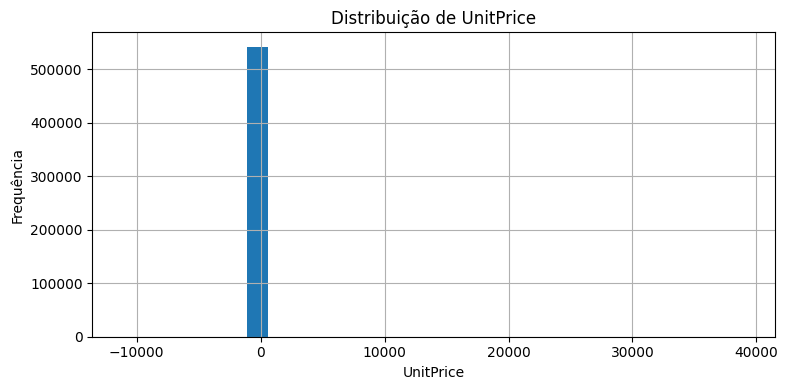

In [32]:
plot_distribuicao_numerica(df, "UnitPrice") #Com outliers

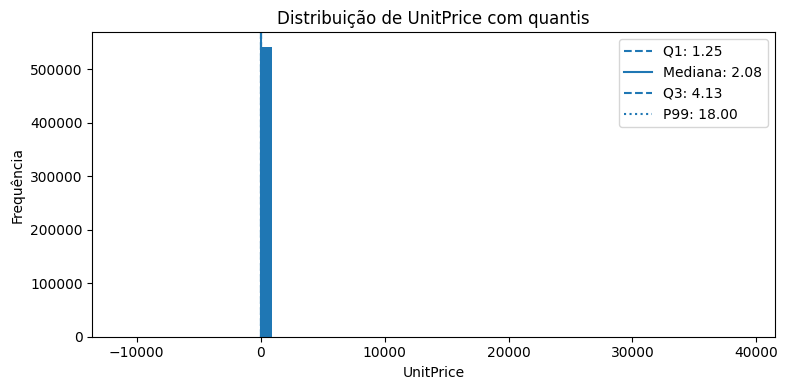

In [33]:
plot_distribuicao_com_quantis(df, "UnitPrice")

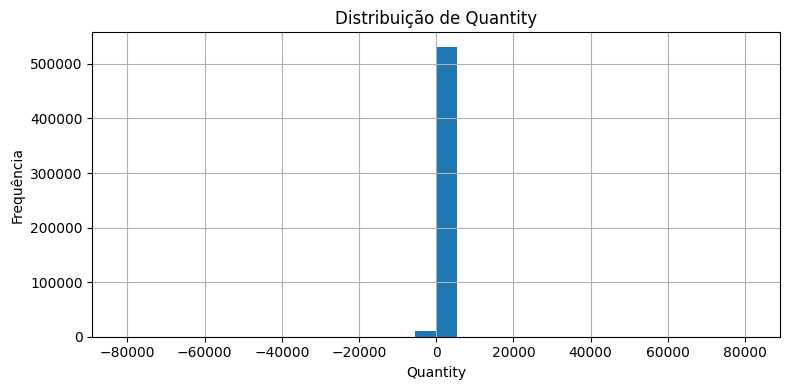

In [34]:
plot_distribuicao_numerica(df, "Quantity") #Com outliers

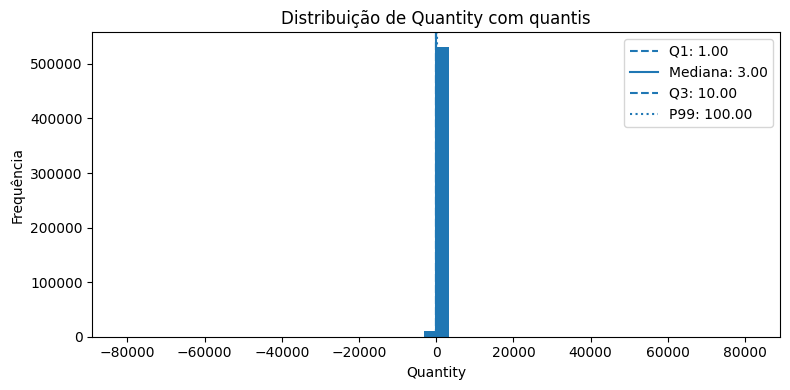

In [35]:
plot_distribuicao_com_quantis(df, "Quantity")

In [36]:
def plot_distribuicao_numerica(df: pd.DataFrame, coluna: str) -> None:
    dados = df[coluna].dropna()

    # remove valores inválidos
    dados = dados[dados > 0]

    #remove outliers (top 1%)
    limite = dados.quantile(0.99)
    dados = dados[dados <= limite]

    plt.figure(figsize=(8, 4))
    plt.hist(dados, bins=50)
    plt.title(f"Distribuição de {coluna}")
    plt.xlabel(coluna)
    plt.ylabel("Frequência")
    plt.tight_layout()
    plt.show()

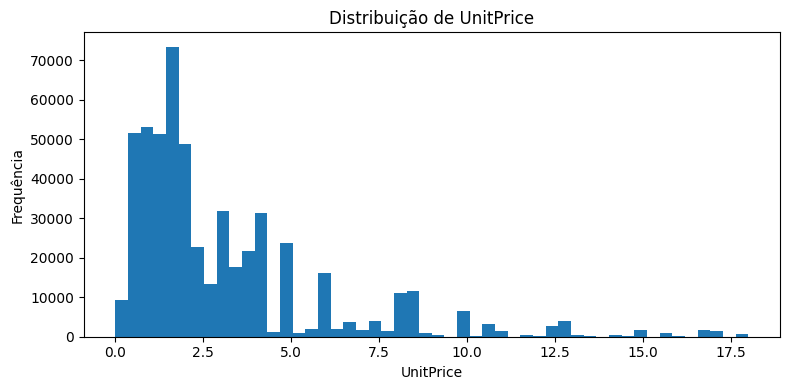

In [37]:
plot_distribuicao_numerica(df, "UnitPrice") #Sem outliers

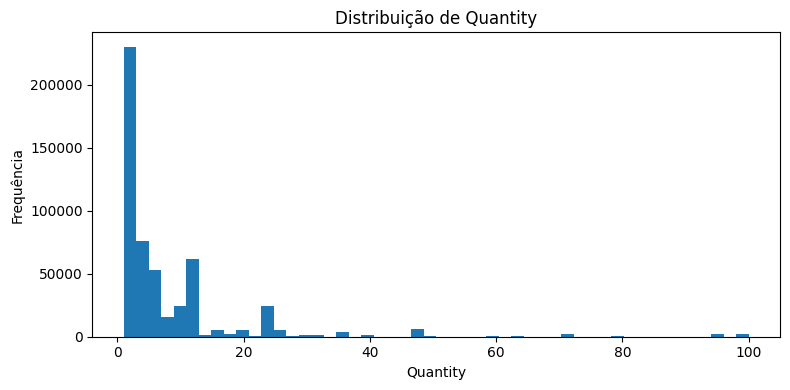

In [38]:
plot_distribuicao_numerica(df, "Quantity") #Sem outliers

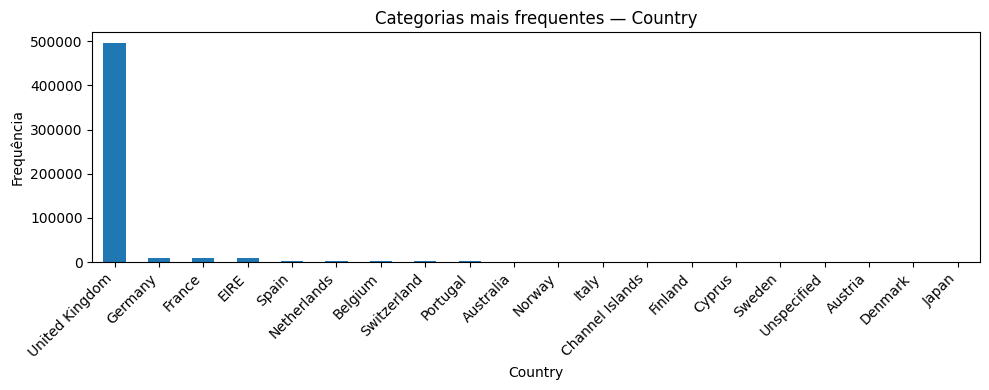

In [39]:
plot_contagem_categorica(df,"Country")

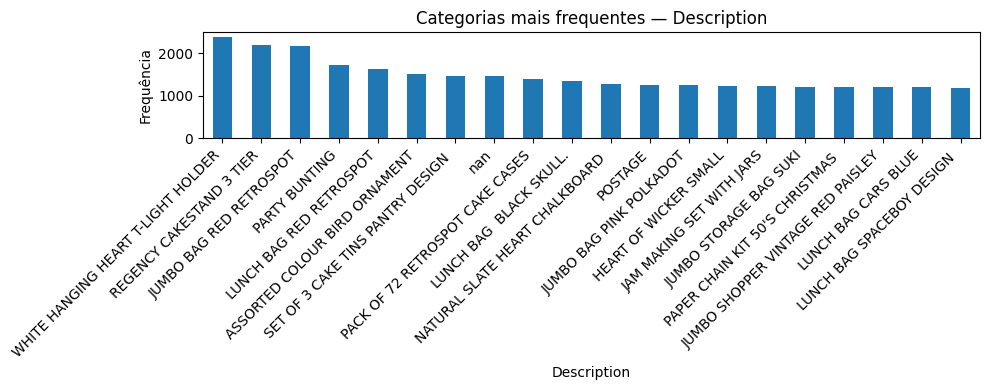

In [40]:
plot_contagem_categorica(df,"Description")

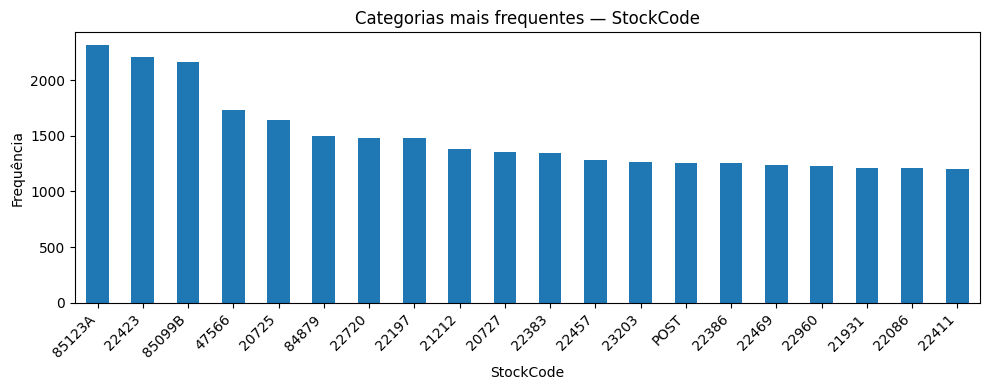

In [41]:
plot_contagem_categorica(df,"StockCode")

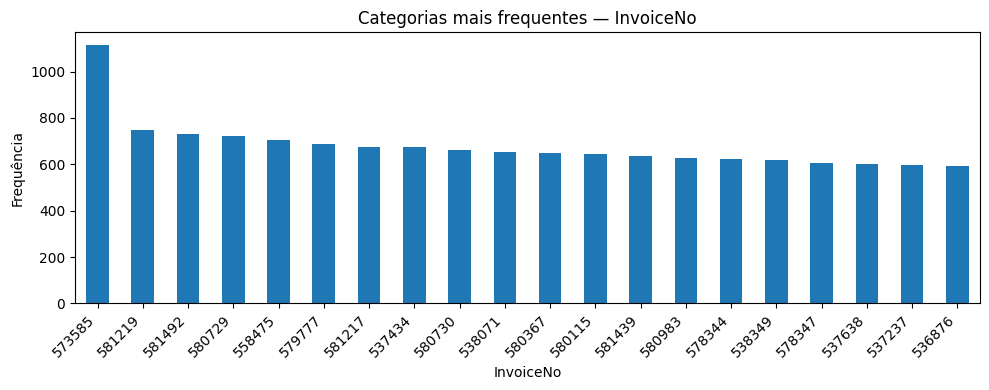

In [42]:
plot_contagem_categorica(df,"InvoiceNo")

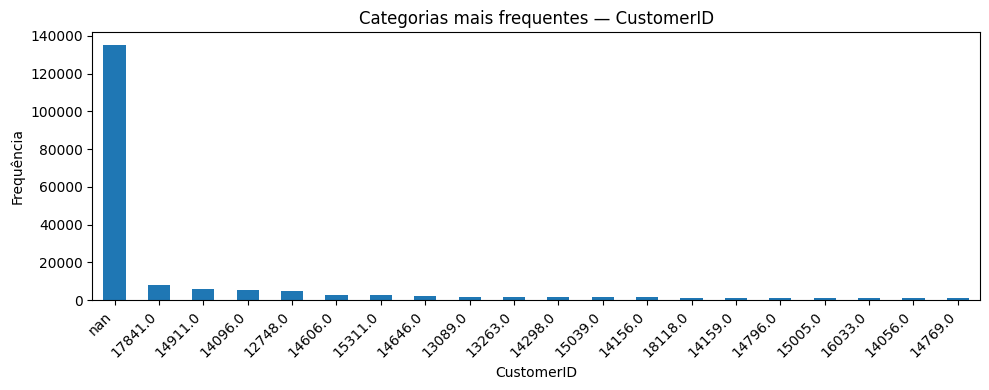

In [43]:
plot_contagem_categorica(df,"CustomerID") 

In [44]:
def detectar_outliers_percentil(
    df: pd.DataFrame, 
    coluna: str, 
    lower_q: float = 0.01, 
    upper_q: float = 0.99,
    apenas_positivos: bool = True
) -> pd.DataFrame:
    
    serie = df[coluna].dropna()

    if apenas_positivos:
        serie = serie[serie > 0]

    limite_inferior = serie.quantile(lower_q)
    limite_superior = serie.quantile(upper_q)

    outliers = df[
        (df[coluna] < limite_inferior) | 
        (df[coluna] > limite_superior)
    ]

    print(f"Coluna: {coluna}")
    print(f"Percentil inferior ({lower_q*100}%): {limite_inferior}")
    print(f"Percentil superior ({upper_q*100}%): {limite_superior}")
    print(f"Número de outliers: {len(outliers)}")

    return outliers

In [45]:
outliers = detectar_outliers_percentil(df, "Quantity")
display(outliers.head())

Coluna: Quantity
Percentil inferior (1.0%): 1.0
Percentil superior (99.0%): 100.0
Número de outliers: 15574


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
96,536378,21212,PACK OF 72 RETROSPOT CAKE CASES,120,01/12/2010 09:37,0.42,14688.0,United Kingdom
141,C536379,D,Discount,-1,01/12/2010 09:41,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,01/12/2010 09:49,4.65,15311.0,United Kingdom
178,536387,79321,CHILLI LIGHTS,192,01/12/2010 09:58,3.82,16029.0,United Kingdom
179,536387,22780,LIGHT GARLAND BUTTERFILES PINK,192,01/12/2010 09:58,3.37,16029.0,United Kingdom


In [46]:
outliers = detectar_outliers_percentil(df, "UnitPrice")
display(outliers.head())

Coluna: UnitPrice
Percentil inferior (1.0%): 0.29
Percentil superior (99.0%): 18.0
Número de outliers: 11618


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,01/12/2010 09:41,27.50,14527.0,United Kingdom
168,536385,22783,SET 3 WICKER OVAL BASKETS W LIDS,1,01/12/2010 09:56,19.95,17420.0,United Kingdom
219,536390,20668,DISCO BALL CHRISTMAS DECORATION,288,01/12/2010 10:19,0.10,17511.0,United Kingdom
246,536392,22827,RUSTIC SEVENTEEN DRAWER SIDEBOARD,1,01/12/2010 10:29,165.00,13705.0,United Kingdom
294,536396,22803,IVORY EMBROIDERED QUILT,2,01/12/2010 10:51,35.75,17850.0,United Kingdom


## 2.2 Análise visual e principais insights

A análise deve responder:

- Há distribuições muito assimétricas?

Sim. As distribuições observadas apresentam forte assimetria, principalmente nas variáveis categóricas relacionadas a produtos e países. O país United Kingdom concentra grande parte das transações do dataset, evidenciando desbalanceamento geográfico. Além disso, poucos produtos concentram elevada frequência de compras, enquanto a maioria aparece poucas vezes. Nas variáveis numéricas Quantity e UnitPrice, a maior parte dos registros está concentrada em valores baixos, com caudas longas formadas por valores muito elevados.

- Existem valores extremos relevantes?

Sim. Foram identificados valores extremos (outliers) tanto em Quantity quanto em UnitPrice, incluindo valores negativos. Esses casos estão associados principalmente a devoluções, cancelamentos ou inconsistências operacionais. Tais valores negativos podem distorcer métricas estatísticas, visualizações e padrões minerados, justificando sua remoção durante a etapa de preparação dos dados.

- Existem categorias raras?

Sim. Variáveis como StockCode e Description apresentam milhares de categorias distintas, sendo que muitos produtos aparecem poucas vezes no conjunto de dados. Essas categorias raras possuem baixo suporte e tendem a contribuir pouco para regras de associação relevantes, além de aumentarem a complexidade computacional da mineração de padrões frequentes.

- Há relações visuais relevantes entre atributos?

Sim. As visualizações mostram forte relação entre InvoiceNo e os produtos associados às transações, evidenciando a estrutura de cestas de compras com múltiplos itens. Também foi observada alta recorrência de determinados produtos em diferentes transações, indicando potenciais padrões de coocorrência relevantes para a mineração de regras de associação.

- Alguma visualização indica limitação da análise?

Sim. O forte desbalanceamento dos produtos e do país predominante pode limitar a generalização dos padrões encontrados. Além disso, a elevada cardinalidade de atributos como Description e StockCode pode gerar explosão combinatória na criação de itemsets, aumentando o custo computacional e dificultando a interpretação dos resultados. As visualizações também indicaram que produtos extremamente frequentes podem gerar regras triviais, reforçando a necessidade de utilizar métricas como Lift e estratégias de filtragem para melhorar a qualidade analítica das associações descobertas.

> Não invente insights. Toda afirmação deve estar apoiada em gráfico, tabela, estatística descritiva ou inspeção documentada.

In [47]:
# Verificação simples de duplicatas, nulos e possíveis identificadores

def diagnostico_qualidade(df: pd.DataFrame) -> dict:
    if df is None:
        print("Dataset não carregado.")
        return {}

    diagnostico = {
        "n_linhas": df.shape[0],
        "n_colunas": df.shape[1],
        "n_duplicatas_exatas": int(df.duplicated().sum()),
        "colunas_com_nulos": df.columns[df.isna().any()].tolist(),
        "colunas_possiveis_ids": []
    }

    for col in df.columns:
        proporcao_unicos = df[col].nunique(dropna=True) / max(len(df), 1)
        if proporcao_unicos > 0.95:
            diagnostico["colunas_possiveis_ids"].append(col)

    return diagnostico

# Exemplo de uso:
diagnostico = diagnostico_qualidade(df)
print(json.dumps(diagnostico, indent=2, ensure_ascii=False))

{
  "n_linhas": 541909,
  "n_colunas": 8,
  "n_duplicatas_exatas": 5268,
  "colunas_com_nulos": [
    "Description",
    "CustomerID"
  ],
  "colunas_possiveis_ids": []
}


## 2.3 Diagnóstico final de qualidade dos dados

| Problema identificado | Evidência | Decisão final | Justificativa |
|---|---|---|---|
| Valores ausentes em Description | Existem 1454 valores ausentes em Description | REMOVER | Embora fosse tecnicamente viável utilizar o atributo StockCode para contornar a ausência, optou-se pela remoção destes registros para focar exclusivamente no uso da Description. Essa decisão visa garantir a explicabilidade e a interpretabilidade do modelo, uma vez que regras de associação compostas apenas por códigos alfanuméricos dificultam a análise de negócios e a compreensão clara de quais produtos reais estão sendo associados. |
| Duplicatas | Existem 5268 valores duplicados | REMOVER | Linhas duplicadas podem inflar artificialmente a frequência de itens e distorcer medidas como suporte, levando a regras enviesadas.|
| Negativos/outliers em Quantity | Existem 10624 valores negativos em Quantity | REMOVER OS NEGATIVOS | Valores negativos representam devoluções, que não refletem coocorrência de compra. Sua remoção garante que apenas eventos de aquisição sejam considerados. |
| Alta cardinalidade em Description e StockCode   | Existem milhares de produtos distintos e muitos itens aparecem poucas vezes no dataset.  | FILTRAR ITENS RAROS E PRIORIZAR Description    |  A elevada cardinalidade aumenta a esparsidade e o custo computacional da mineração de padrões frequentes. A remoção de itens raros reduz explosão combinatória, enquanto o uso de Description melhora interpretabilidade e explicabilidade das regras geradas.
| Categorias raras | Muitas transações envolvem apenas 1 item | REMOVER | Itens com baixa frequência não geram padrões estatisticamente relevantes e aumentam a esparsidade da matriz, prejudicando eficiência e qualidade das regras. |
|Atributos identificadores | InvoiceNo identifica transações e CustomerID identifica clientes anonimizados. | REMOVER CustomerID DO MODELO  | Esses atributos possuem função apenas identificadora e não contribuem diretamente para a descoberta de padrões de coocorrência entre produtos. O atributo InvoiceNo foi utilizado apenas para estruturar as cestas de compras, enquanto CustomerID foi removido por estar fora do escopo analítico do projeto.| 
|Atributos sensíveis |  Não foram identificados atributos pessoais sensíveis explícitos no dataset. | MANTER USO ÉTICO E REMOVER CustomerID DA MODELAGEM  | O dataset apresenta baixo risco de privacidade, pois não contém informações pessoais diretas, como nome, endereço, gênero ou renda. Ainda assim, CustomerID pode funcionar como identificador indireto anonimizado. Por precaução ética e por não ser necessário para a tarefa proposta, optou-se por remover esse atributo da modelagem final. | 


### Observação sobre responsabilidade

As decisões relacionadas à qualidade dos dados foram diretamente influenciadas pelas diretrizes de IA responsável adotadas no projeto, sendo elas:  Explicabilidade e Eficiência e Escalabilidade.

A remoção de valores inconsistentes, duplicatas e transações inválidas buscou aumentar a confiabilidade dos padrões descobertos, evitando que regras de associação fossem influenciadas por erros operacionais, devoluções ou registros redundantes. Essa decisão contribui tanto para a qualidade analítica quanto para a interpretabilidade dos resultados.

A priorização da coluna Description em vez de StockCode também foi motivada pela diretriz de explicabilidade. Embora códigos técnicos possam oferecer maior consistência computacional, descrições textuais tornam as regras muito mais compreensíveis para usuários de negócio, facilitando interpretação, validação e aplicação prática dos padrões encontrados.

Já a remoção de variáveis fora do escopo da tarefa, como Country, InvoiceDate e CustomerID, esteve relacionada principalmente à eficiência e escalabilidade. Reduzir atributos irrelevantes diminui complexidade computacional, melhora foco analítico e evita aumento desnecessário da dimensionalidade do problema.

Do ponto de vista ético e de privacidade, o dataset apresenta baixo risco por não conter atributos pessoais sensíveis explícitos. Ainda assim, o atributo CustomerID poderia funcionar como identificador indireto anonimizado. Mesmo não sendo utilizado diretamente na modelagem, optou-se por removê-lo da análise final como medida preventiva e por não agregar valor à mineração de regras de associação entre produtos.

Além disso, a remoção de categorias muito raras e o controle do número de regras geradas buscaram equilibrar desempenho computacional e clareza analítica. Embora essa decisão possa reduzir a descoberta de padrões menos frequentes, ela favorece a obtenção de regras mais relevantes, interpretáveis e úteis para apoio à tomada de decisão.

In [50]:
import pandas as pd
import numpy as np

def preparar_dados_final(
    df: pd.DataFrame,
    min_itens_por_transacao: int = 2,
    min_freq_item: int = 5
) -> pd.DataFrame:
    """
    Preparação de dados para mineração de regras de associação (FP-Growth).
    """

    df_prep = df.copy()

    # 1. Remover duplicatas

    df_prep = df_prep.drop_duplicates()


    # 2. Remover variáveis fora do escopo da análise / variáveis que optamos por não utilizar na análise

    colunas_remover = ["Country", "InvoiceDate", "CustomerID", "StockCode"]

    colunas_existentes = [
        col for col in colunas_remover
        if col in df_prep.columns
    ]

    df_prep = df_prep.drop(columns=colunas_existentes)


    # 3. Tratamento de valores nulos


    # Remove linhas sem descrição do item
    if "Description" in df_prep.columns:
        df_prep = df_prep.dropna(subset=["Description"])

    # 4. Padronização textual da Description

    if "Description" in df_prep.columns:
        df_prep["Description"] = (
            df_prep["Description"]
            .astype(str)
            .str.strip()
            .str.upper()
        )

    # 5. Remover transações canceladas
    # InvoiceNo iniciado por "C" representa cancelamento
    if "InvoiceNo" in df_prep.columns:
        df_prep = df_prep[
            ~df_prep["InvoiceNo"]
            .astype(str)
            .str.startswith("C")
        ]


    # 6. Remover devoluções e valores inválidos

    if "Quantity" in df_prep.columns:
        df_prep = df_prep[df_prep["Quantity"] > 0]

    if "UnitPrice" in df_prep.columns:
        df_prep = df_prep[df_prep["UnitPrice"] > 0]


    # 7. Verificar colunas obrigatórias

    if not {"InvoiceNo", "Description"}.issubset(df_prep.columns):
        raise ValueError(
            "O dataset precisa conter 'InvoiceNo' e 'Description'."
        )


    # 8. Criar matriz transacional (basket)

    basket = (
        df_prep.groupby(["InvoiceNo", "Description"])["Quantity"]
        .sum()
        .unstack()
        .fillna(0)
    )
    print("DF PREPARADO: ")
    display(df_prep.head())
    print(df_prep.shape)


    # 9. Binarização (presença/ausência)

    basket = (basket > 0).astype(int)


    # 10. Remover itens raros

    item_freq = basket.sum(axis=0)

    itens_filtrados = item_freq[
        item_freq >= min_freq_item
    ].index

    basket = basket[itens_filtrados]

    # 11. Remover transações muito pequenas

    basket = basket[
        basket.sum(axis=1) >= min_itens_por_transacao
    ]


    # 12. Resetar índice

    basket = basket.reset_index(drop=True)

    return basket

# Exemplo de uso:
basket = preparar_dados_final(df)
print("BASKET: ")
display(basket.head())
print(basket.shape)

DF PREPARADO: 


,InvoiceNo,Description,Quantity,UnitPrice
0,536365,WHITE HANGING HEART T-LIGHT HOLDER,6,2.55
1,536365,WHITE METAL LANTERN,6,3.39
2,536365,CREAM CUPID HEARTS COAT HANGER,8,2.75
3,536365,KNITTED UNION FLAG HOT WATER BOTTLE,6,3.39
4,536365,RED WOOLLY HOTTIE WHITE HEART.,6,3.39


(524878, 4)
BASKET: 


Description,10 COLOUR SPACEBOY PEN,12 COLOURED PARTY BALLOONS,12 DAISY PEGS IN WOOD BOX,12 EGG HOUSE PAINTED WOOD,12 HANGING EGGS HAND PAINTED,12 IVORY ROSE PEG PLACE SETTINGS,12 MESSAGE CARDS WITH ENVELOPES,12 PENCIL SMALL TUBE WOODLAND,12 PENCILS SMALL TUBE RED RETROSPOT,12 PENCILS SMALL TUBE SKULL,...,ZINC HERB GARDEN CONTAINER,ZINC METAL HEART DECORATION,ZINC SWEETHEART SOAP DISH,ZINC SWEETHEART WIRE LETTER RACK,ZINC T-LIGHT HOLDER STAR LARGE,ZINC T-LIGHT HOLDER STARS SMALL,ZINC TOP 2 DOOR WOODEN SHELF,ZINC WILLIE WINKIE CANDLE STICK,ZINC WIRE KITCHEN ORGANISER,ZINC WIRE SWEETHEART LETTER TRAY
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


(18305, 3521)


## 2.4 Justificativa da preparação final

A preparação final dos dados teve como objetivo garantir qualidade, interpretabilidade e eficiência para a tarefa de mineração de regras de associação utilizando o algoritmo FP-Growth. As transformações realizadas buscaram reduzir inconsistências, eliminar informações irrelevantes para a tarefa e estruturar os dados em formato adequado para análise transacional.

Inicialmente, foram removidas colunas consideradas fora do escopo analítico principal do projeto, como Country, InvoiceDate e CustomerID. A variável Country não seria utilizada na descoberta de associações entre produtos, enquanto InvoiceDate exigiria análises temporais que não fazem parte dos objetivos definidos. Já CustomerID, apesar de funcionar como identificador anonimizado, não contribui diretamente para a mineração de padrões de coocorrência entre itens e foi removido também por questões de simplificação e responsabilidade no uso dos dados.

Os valores ausentes foram tratados de forma seletiva. Registros sem Description foram removidos, pois a coluna foi definida como principal representação dos produtos devido à sua interpretabilidade e contribuição para a explicabilidade das regras geradas. Embora fosse possível utilizar StockCode como alternativa técnica, essa abordagem foi descartada por dificultar a compreensão dos resultados por usuários de negócio. Assim, removemos também a variável StockCode e priorizamos Description.

Também foram removidos registros duplicados, evitando que determinadas transações fossem contabilizadas mais de uma vez e distorcessem métricas como suporte, confiança e lift. Além disso, transações canceladas — identificadas por InvoiceNo iniciado pela letra “C” — foram excluídas, assim como registros contendo valores negativos em Quantity e UnitPrice, associados principalmente a devoluções, cancelamentos ou inconsistências operacionais.

Foi realizada ainda uma etapa de padronização textual da coluna Description, incluindo remoção de espaços extras e conversão para letras maiúsculas. Essa normalização teve como objetivo evitar que o mesmo produto fosse tratado como itens distintos devido a diferenças de formatação textual, reduzindo inconsistências e melhorando a qualidade dos padrões encontrados.

Após o tratamento inicial, os dados foram agregados em formato transacional (“basket”), agrupando produtos por InvoiceNo. Em seguida, a matriz foi binarizada, representando apenas presença ou ausência de itens nas transações, estrutura necessária para aplicação do algoritmo FP-Growth. Assim, essa preparação foi toda pensada para a próxima tarefa que envolve o desenvolvimento do algoritmo.

Também foi aplicada filtragem de itens raros e remoção de transações muito pequenas. Produtos com frequência extremamente baixa tendem a gerar regras pouco relevantes e aumentam significativamente a esparsidade e o custo computacional da mineração. Da mesma forma, transações contendo apenas um item não contribuem para descoberta de associações entre produtos e foram removidas.

Parte das decisões de preparação foi baseada nas recomendações da baseline e da trilha guiada da disciplina, especialmente em relação à remoção de duplicatas, tratamento de valores inconsistentes, filtragem de transações inadequadas e estruturação dos dados em formato transacional para mineração de regras de associação. A utilização da coluna Description como principal representação dos produtos foi reforçada pelas orientações da trilha guiada, devido à sua maior interpretabilidade.

Além disso, o grupo realizou decisões complementares específicas para o contexto do projeto, como a remoção antecipada de variáveis que não seriam utilizadas na modelagem (Country, InvoiceDate e CustomerID), a aplicação de padronização textual na coluna Description e a definição de estratégias para reduzir a complexidade computacional, incluindo filtragem de itens raros e controle do volume final de regras geradas. Essas escolhas buscaram equilibrar eficiência, qualidade analítica e explicabilidade dos resultados.

As sugestões levantadas com apoio da LLM em relação à preparação dos dados foram, em geral, confirmadas durante a exploração real do dataset, especialmente no que diz respeito à remoção de duplicatas, tratamento de valores inconsistentes, exclusão de devoluções/cancelamentos e necessidade de estruturar os dados em formato transacional para mineração de regras de associação. Essas recomendações mostraram-se coerentes com os problemas efetivamente encontrados na base.

Entretanto, algumas decisões adicionais foram definidas pelo próprio grupo após análise mais detalhada dos dados. Entre elas, destacam-se a remoção prévia de colunas consideradas irrelevantes para a tarefa (Country, InvoiceDate e CustomerID) e a realização de padronização textual da coluna Description, incluindo normalização de formatação e capitalização. Essas etapas não haviam sido sugeridas inicialmente pela LLM, mas foram incorporadas para reduzir inconsistências, simplificar a modelagem e melhorar a qualidade e interpretabilidade das regras geradas.

In [51]:
#NOSSO GRUPO NÃO PRECISOU DESSA FUNÇÃO, POIS JÁ CRIAMOS A MATRIZ BASKET EM PREPARAR_DADOS_FINAL

# Preparações específicas por tipo de tarefa
# Use apenas o bloco correspondente ao TASK_TYPE do trabalho.

from typing import List, Tuple, Optional


def gerar_transacoes_de_coluna(df: pd.DataFrame, coluna: str, separador: str = ",") -> List[List[str]]:
    """Gera transações para mineração de padrões frequentes a partir de uma coluna textual."""
    transacoes = []

    for valor in df[coluna].dropna():
        itens = [item.strip().lower() for item in str(valor).split(separador) if item.strip()]
        if itens:
            transacoes.append(itens)

    return transacoes

# Exemplos de uso:
#transacoes = gerar_transacoes_de_coluna(df_prep, TRANSACTION_COLUMN)

# 3. Modeling

Nesta seção, o grupo deve implementar a solução final.

A modelagem final deve ser resultado de uma decisão crítica, não de simples cópia da LLM.

A seção deve deixar claro:

- quais algoritmos foram testados;
- quais parâmetros foram usados;
- por que esses algoritmos foram escolhidos;
- o que foi inspirado pela baseline;
- o que foi inspirado pela trilha guiada;
- o que foi corrigido ou decidido pelo grupo;
- como a implementação se relaciona às diretrizes de IA responsável.

## 3.1 Comparação entre baseline, guiada e solução final

| Elemento | Sugestão baseline | Sugestão guiada | Solução final do grupo | Justificativa da decisão final |
|---|---|---|---|---|
| Algoritmo(s) | Utilização apenas do FP-Growth | Utilizar mais de um algoritmo e compará-los (mas reforçando as vantagens do FP-Growth) | Utilização apenas do FP-Growth. | O FP-Growth apresentou melhor alinhamento com as necessidades do projeto, oferecendo maior eficiência e escalabilidade para lidar com o grande volume de transações do dataset, além de evitar explosão combinatória excessiva. |
| Preparação dos dados | Remoção de duplicatas, tratamento de valores inconsistentes e organização transacional. | Remover devoluções/cancelamentos, tratar valores ausentes e utilizar atributos relevantes para regras de associação. | Remoção de duplicatas, exclusão de cancelamentos e valores negativos, remoção de variáveis fora do escopo (Country, InvoiceDate e CustomerID), padronização textual de Description, filtragem de itens raros e criação da basket matrix binarizada. | As decisões buscaram melhorar qualidade dos dados, interpretabilidade das regras e eficiência computacional da mineração. |
| Parâmetros | Utilizar suporte e confiança mínimos fixos ou tentar uma estratégia iterativa. | Utilizar suporte e confiança mínimos fixos pensados especificamente para o nosso problema. | Estratégia iterativa com suporte mínimo fixo de 1% e confiança inicial de 80%, reduzida gradualmente em intervalos de 5%, até alcançar um conjunto de regras com volume adequado para análise e interpretação. | A exploração iterativa permitiu equilibrar quantidade de regras, qualidade analítica, interpretabilidade e custo computacional. |
| Métricas |Uso de suporte e confiança como métricas principais.| Uso de suporte, confiança, lift e convicção. | Priorização do Lift, complementado por suporte, confiança e convicção. | O Lift mostrou-se mais adequado para evitar regras triviais envolvendo itens muito frequentes e destacar associações mais relevantes. |
| Estratégia de avaliação | Avaliar quantidade de regras geradas e suporte mínimo. | Avaliar relevância, interpretabilidade e redundância das regras. | Avaliação baseada em Lift, interpretabilidade das associações, volume controlado de regras e relevância prática para o negócio. | O objetivo não é apenas gerar muitas regras, mas identificar padrões úteis, compreensíveis e acionáveis para apoio à tomada de decisão. |
| Cuidados de IA responsável | Pouco detalhados na baseline, mas focou na eficiência computacional, sugerindo o uso do FP-Growth. | Ênfase em explicabilidade e eficiência computacional. Priorização da interpretabilidade via Description. | Aceitar sugestões da LLM, utilizar FP_Growth, além de remover atributos desnecessários e buscar reduzir a quantidade de regras triviais. | As decisões tomadas buscaram garantir que as regras geradas fossem não apenas computacionalmente viáveis, mas também compreensíveis e úteis para os usuários de negócio, priorizando interpretabilidade, redução de complexidade desnecessária e maior qualidade analítica dos padrões encontrados. |

### Síntese da decisão final

A solução final adotada para o projeto de mineração de regras de associação utiliza exclusivamente o algoritmo FP-Growth, devido à sua maior eficiência e escalabilidade em comparação ao Apriori, que não se mostrou viável para o volume de dados analisado, especialmente considerando o alto número de transações e a alta cardinalidade dos itens.

O FP-Growth foi escolhido por permitir a geração de padrões frequentes de forma mais eficiente, evitando a geração explícita de candidatos e reduzindo significativamente o custo computacional. O algoritmo foi aplicado sobre a matriz transacional (basket), construída a partir do agrupamento de InvoiceNo e Description e posteriormente binarizada para representar a presença ou ausência de itens em cada cesta de compras.

Após a definição da estrutura de dados e do algoritmo, foi adotada uma estratégia exploratória para definição dos parâmetros, com ajuste iterativo do suporte mínimo e da confiança mínima. O suporte foi inicialmente fixado em 1%, enquanto a confiança foi ajustada progressivamente em diferentes níveis (redução gradual em intervalos de 5%), permitindo equilibrar o número de regras geradas e sua qualidade analítica. 

Essa abordagem final foi escolhida por oferecer o melhor compromisso entre eficiência computacional, interpretabilidade dos resultados e qualidade das regras geradas, garantindo padrões relevantes e acionáveis para apoio à tomada de decisão no contexto do varejo.

A solução final não precisa ser idêntica à melhor resposta da LLM. Ela deve ser tecnicamente defensável e baseada em evidências.

In [ ]:
# Registro simples de experimentos
# Ajuda a manter rastreabilidade de parâmetros e resultados.

experimentos = []


def registrar_experimento(nome: str, algoritmo: str, parametros: dict, metricas: dict, observacoes: str = ""):
    registro = {
        "timestamp": datetime.now().isoformat(timespec="seconds"),
        "nome": nome,
        "algoritmo": algoritmo,
        "parametros": parametros,
        "metricas": metricas,
        "observacoes": observacoes
    }
    experimentos.append(registro)
    return registro


def salvar_experimentos(caminho: str = os.path.join(OUTPUT_DIR, "experimentos.json")):
    with open(caminho, "w", encoding="utf-8") as f:
        json.dump(experimentos, f, indent=2, ensure_ascii=False)
    print(f"Experimentos salvos em: {caminho}")

# Exemplo:
# registrar_experimento(
#     nome="teste_inicial",
#     algoritmo="Apriori",
#     parametros={"min_support": 0.05, "min_confidence": 0.6},
#     metricas={"n_regras": 100, "tempo_segundos": 1.23},
#     observacoes="Teste preliminar."
# )

## 3.2 Modelagem para padrões frequentes

Use esta seção se o TP atual for de mineração de padrões frequentes.

Caso o TP seja de agrupamento ou classificação, mantenha apenas como referência e utilize as seções correspondentes abaixo.

In [ ]:
# Modelagem para padrões frequentes: Apriori e FP-Growth
# Esta célula depende de mlxtend. Instale se necessário: pip install mlxtend

def executar_padroes_frequentes(transacoes, min_support=0.05, min_confidence=0.6):
    try:
        from mlxtend.preprocessing import TransactionEncoder
        from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules
    except ImportError:
        print("Biblioteca mlxtend não instalada. Instale com: pip install mlxtend")
        return None

    te = TransactionEncoder()
    matriz = te.fit(transacoes).transform(transacoes)
    df_transacoes = pd.DataFrame(matriz, columns=te.columns_)

    resultados = {}

    inicio = time.time()
    itemsets_apriori = apriori(df_transacoes, min_support=min_support, use_colnames=True)
    regras_apriori = association_rules(itemsets_apriori, metric="confidence", min_threshold=min_confidence)
    tempo_apriori = time.time() - inicio

    resultados["Apriori"] = {
        "itemsets": itemsets_apriori,
        "regras": regras_apriori,
        "tempo_segundos": tempo_apriori
    }

    inicio = time.time()
    itemsets_fpgrowth = fpgrowth(df_transacoes, min_support=min_support, use_colnames=True)
    regras_fpgrowth = association_rules(itemsets_fpgrowth, metric="confidence", min_threshold=min_confidence)
    tempo_fpgrowth = time.time() - inicio

    resultados["FP-Growth"] = {
        "itemsets": itemsets_fpgrowth,
        "regras": regras_fpgrowth,
        "tempo_segundos": tempo_fpgrowth
    }

    return resultados


def resumir_padroes_frequentes(resultados):
    if resultados is None:
        return pd.DataFrame()

    linhas = []

    for algoritmo, info in resultados.items():
        itemsets = info["itemsets"]
        regras = info["regras"]

        linhas.append({
            "algoritmo": algoritmo,
            "n_itemsets": len(itemsets),
            "n_regras": len(regras),
            "tempo_segundos": round(info["tempo_segundos"], 4),
            "confianca_media": regras["confidence"].mean() if len(regras) > 0 else np.nan,
            "lift_medio": regras["lift"].mean() if len(regras) > 0 and "lift" in regras.columns else np.nan
        })

    return pd.DataFrame(linhas)

# Exemplo de uso:
# transacoes = gerar_transacoes_de_coluna(df_prep, TRANSACTION_COLUMN)
# resultados_padroes = executar_padroes_frequentes(transacoes, min_support=0.05, min_confidence=0.6)
# resumo_padroes = resumir_padroes_frequentes(resultados_padroes)
# display(resumo_padroes)

## 3.3 Modelagem para agrupamento

Use esta seção se o TP atual for de clusterização.

A avaliação de agrupamento deve considerar métricas internas, interpretação dos grupos e coerência com o problema. Não basta reportar o número de clusters.

In [ ]:
# Modelagem para agrupamento: K-Means e DBSCAN
# Adapte os algoritmos conforme a proposta do grupo.


def executar_agrupamento_basico(X: pd.DataFrame):
    try:
        from sklearn.preprocessing import StandardScaler
        from sklearn.cluster import KMeans, DBSCAN
        from sklearn.metrics import silhouette_score, davies_bouldin_score
    except ImportError:
        print("scikit-learn não está instalado.")
        return pd.DataFrame(), {}

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    resultados = []
    modelos = {}

    # K-Means com alguns valores de k como exemplo.
    for k in [2, 3, 4, 5]:
        inicio = time.time()
        modelo = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
        labels = modelo.fit_predict(X_scaled)
        tempo = time.time() - inicio

        if len(set(labels)) > 1:
            sil = silhouette_score(X_scaled, labels)
            db = davies_bouldin_score(X_scaled, labels)
        else:
            sil = np.nan
            db = np.nan

        nome = f"KMeans_k{k}"
        modelos[nome] = modelo
        resultados.append({
            "modelo": nome,
            "n_clusters": len(set(labels)),
            "silhouette": sil,
            "davies_bouldin": db,
            "tempo_segundos": tempo
        })

    # DBSCAN com parâmetros de exemplo.
    inicio = time.time()
    dbscan = DBSCAN(eps=0.5, min_samples=5)
    labels = dbscan.fit_predict(X_scaled)
    tempo = time.time() - inicio

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    if n_clusters > 1:
        sil = silhouette_score(X_scaled, labels)
        db = davies_bouldin_score(X_scaled, labels)
    else:
        sil = np.nan
        db = np.nan

    modelos["DBSCAN"] = dbscan
    resultados.append({
        "modelo": "DBSCAN",
        "n_clusters": n_clusters,
        "silhouette": sil,
        "davies_bouldin": db,
        "tempo_segundos": tempo
    })

    return pd.DataFrame(resultados), modelos

# Exemplo de uso:
# X, _ = preparar_matriz_modelagem(df_prep, target_column=None)
# resultados_cluster, modelos_cluster = executar_agrupamento_basico(X)
# display(resultados_cluster)

## 3.4 Modelagem para classificação

Use esta seção se o TP atual for de classificação.

A avaliação deve usar uma separação adequada entre treino e teste ou validação cruzada, além de métricas coerentes com o problema, especialmente se houver desbalanceamento de classes.

In [ ]:
# Modelagem para classificação: exemplos com árvore, regressão logística e random forest
# Adapte os modelos conforme a proposta do grupo.


def executar_classificacao_basica(X: pd.DataFrame, y: pd.Series, test_size: float = 0.2):
    try:
        from sklearn.model_selection import train_test_split
        from sklearn.preprocessing import StandardScaler
        from sklearn.pipeline import Pipeline
        from sklearn.tree import DecisionTreeClassifier
        from sklearn.linear_model import LogisticRegression
        from sklearn.ensemble import RandomForestClassifier
        from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
    except ImportError:
        print("scikit-learn não está instalado.")
        return pd.DataFrame(), {}

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=RANDOM_STATE,
        stratify=y if y.nunique() > 1 else None
    )

    modelos = {
        "DecisionTree": DecisionTreeClassifier(random_state=RANDOM_STATE, max_depth=5),
        "LogisticRegression": Pipeline([
            ("scaler", StandardScaler(with_mean=False)),
            ("clf", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
        ]),
        "RandomForest": RandomForestClassifier(random_state=RANDOM_STATE, n_estimators=100)
    }

    resultados = []
    modelos_treinados = {}

    average = "weighted" if y.nunique() > 2 else "binary"

    for nome, modelo in modelos.items():
        inicio = time.time()
        modelo.fit(X_train, y_train)
        y_pred = modelo.predict(X_test)
        tempo = time.time() - inicio

        resultados.append({
            "modelo": nome,
            "accuracy": accuracy_score(y_test, y_pred),
            "precision": precision_score(y_test, y_pred, average=average, zero_division=0),
            "recall": recall_score(y_test, y_pred, average=average, zero_division=0),
            "f1": f1_score(y_test, y_pred, average=average, zero_division=0),
            "tempo_segundos": tempo
        })

        modelos_treinados[nome] = modelo

    return pd.DataFrame(resultados), modelos_treinados

# Exemplo de uso:
# X, y = preparar_matriz_modelagem(df_prep, TARGET_COLUMN)
# resultados_classificacao, modelos_classificacao = executar_classificacao_basica(X, y)
# display(resultados_classificacao)

## 3.5 Resultados da modelagem final

[INSERIR RESULTADOS EFETIVAMENTE OBTIDOS]

Inclua tabelas e comentários sobre:

- algoritmos executados;
- parâmetros usados;
- métricas obtidas;
- tempo de execução;
- estabilidade ou sensibilidade a parâmetros;
- qualidade dos padrões, clusters ou classificações;
- interpretabilidade dos resultados;
- relação com as diretrizes escolhidas.

### Interpretação técnica

[INSERIR INTERPRETAÇÃO]

Evite conclusões vagas. Exemplos de frases fracas:

- “O algoritmo foi bom.”
- “O resultado foi satisfatório.”
- “A LLM ajudou bastante.”

Prefira afirmações verificáveis:

- “O FP-Growth gerou o mesmo conjunto de itemsets que o Apriori, mas com menor tempo de execução neste dataset.”
- “O modelo de árvore teve desempenho inferior, mas permitiu interpretação mais direta das regras de decisão.”
- “O K-Means com k=3 apresentou melhor silhouette entre os valores testados, mas a interpretação dos clusters ainda é limitada.”

# 4. Evaluation

Nesta seção, o grupo deve avaliar a solução final de forma crítica.

A avaliação deve considerar:

- qualidade dos resultados;
- adequação ao problema de negócio;
- desempenho dos algoritmos;
- limitações dos dados;
- limitações da modelagem;
- influência real das LLMs;
- influência real das diretrizes de IA responsável;
- trade-offs observados.

## 4.1 Avaliação dos resultados finais

[INSERIR ANÁLISE DOS RESULTADOS]

A análise deve responder:

- Os resultados são coerentes com o problema?
- Os padrões, clusters ou classificações têm interpretação útil?
- As métricas usadas são adequadas?
- Há sinais de overfitting, instabilidade ou resultado trivial?
- Os resultados dependem fortemente de parâmetros?
- As conclusões são sustentadas pelos dados?

### Limitações dos resultados

[DESCREVER LIMITAÇÕES]

Exemplos:

- dataset desbalanceado;
- atributos pouco informativos;
- ausência de variáveis importantes;
- muitos dados ausentes;
- limitações de escala;
- dificuldade de interpretar padrões numerosos ou redundantes.

## 4.2 Comparação final: baseline × guiada × solução final

| Critério | Baseline sugerida pela LLM | Guiada sugerida pela LLM | Solução final implementada | Avaliação crítica |
|---|---|---|---|---|
| Correção técnica | [ANALISAR] | [ANALISAR] | [ANALISAR] | [COMPARAR] |
| Adequação ao problema | [ANALISAR] | [ANALISAR] | [ANALISAR] | [COMPARAR] |
| Preparação dos dados | [ANALISAR] | [ANALISAR] | [ANALISAR] | [COMPARAR] |
| Algoritmos escolhidos | [ANALISAR] | [ANALISAR] | [ANALISAR] | [COMPARAR] |
| Métricas de avaliação | [ANALISAR] | [ANALISAR] | [ANALISAR] | [COMPARAR] |
| Interpretabilidade | [ANALISAR] | [ANALISAR] | [ANALISAR] | [COMPARAR] |
| Rastreabilidade | [ANALISAR] | [ANALISAR] | [ANALISAR] | [COMPARAR] |
| Eficiência computacional | [ANALISAR] | [ANALISAR] | [ANALISAR] | [COMPARAR] |
| Aderência às diretrizes | [ANALISAR] | [ANALISAR] | [ANALISAR] | [COMPARAR] |

### Conclusão da comparação

[INSERIR CONCLUSÃO COMPARATIVA]

A conclusão deve deixar claro:

- o que a baseline acertou;
- o que a baseline ignorou;
- o que a trilha guiada melhorou;
- o que a trilha guiada ainda errou;
- o que o grupo decidiu implementar;
- por que a solução final é tecnicamente mais defensável.

## 4.3 Sugestões aceitas, rejeitadas e corrigidas

| Sugestão | Origem | Decisão | Justificativa |
|---|---|---|---|
| [SUGESTÃO 1] | Baseline | Aceita / Rejeitada / Corrigida | [JUSTIFICAR] |
| [SUGESTÃO 2] | Guiada | Aceita / Rejeitada / Corrigida | [JUSTIFICAR] |
| [SUGESTÃO 3] | Grupo | Implementada | [JUSTIFICAR] |

### Erros ou limitações das LLMs

| Erro, omissão ou limitação | Trilha | Impacto potencial | Correção feita pelo grupo |
|---|---|---|---|
| [DESCREVER] | Baseline / Guiada | [DESCREVER] | [DESCREVER] |
| [DESCREVER] | Baseline / Guiada | [DESCREVER] | [DESCREVER] |

> O grupo deve demonstrar que avaliou criticamente a LLM. Uma boa entrega não aceita automaticamente todas as recomendações geradas.

## 4.4 Avaliação das diretrizes de IA responsável na solução final

| Diretriz | Como apareceu na Fase 2 | Como foi incorporada na Fase 3 | Evidência no notebook | Limitações |
|---|---|---|---|---|
| [DIRETRIZ 1] | [DESCREVER] | [DESCREVER] | [INSERIR EVIDÊNCIA] | [DESCREVER] |
| [DIRETRIZ 2] | [DESCREVER] | [DESCREVER] | [INSERIR EVIDÊNCIA] | [DESCREVER] |

### Discussão crítica

[INSERIR DISCUSSÃO]

Questões orientadoras:

- A diretriz influenciou apenas o texto ou também o pipeline técnico?
- Houve mudança em atributos, algoritmos, métricas ou interpretação?
- A diretriz melhorou a qualidade da solução?
- Houve custo adicional, perda de desempenho ou aumento de complexidade?
- Alguma diretriz foi difícil de operacionalizar? Por quê?

## 4.5 Trade-offs finais

| Trade-off | Evidência observada | Decisão final | Justificativa |
|---|---|---|---|
| Desempenho × interpretabilidade | [PREENCHER] | [PREENCHER] | [JUSTIFICAR] |
| Privacidade × utilidade dos dados | [PREENCHER] | [PREENCHER] | [JUSTIFICAR] |
| Eficiência × qualidade dos resultados | [PREENCHER] | [PREENCHER] | [JUSTIFICAR] |
| Simplicidade × completude da análise | [PREENCHER] | [PREENCHER] | [JUSTIFICAR] |
| Justiça/viés × disponibilidade de atributos | [PREENCHER] | [PREENCHER] | [JUSTIFICAR] |

### Síntese

[INSERIR SÍNTESE DOS TRADE-OFFS MAIS IMPORTANTES]

Nem todos os trade-offs serão aplicáveis a todos os trabalhos. Discuta apenas os que fizerem sentido para o dataset e para a tarefa.

# 5. Conclusão

[INSERIR CONCLUSÃO FINAL]

A conclusão deve retomar:

1. o objetivo do trabalho;
2. a solução final implementada;
3. os principais resultados obtidos;
4. as limitações da análise;
5. o papel das LLMs;
6. o efeito das diretrizes de IA responsável;
7. possíveis melhorias futuras.

## Exemplo de estrutura de conclusão

> Neste trabalho, investigamos [PROBLEMA] usando o dataset [DATASET] e aplicamos [TÉCNICA]. Após comparar as sugestões da LLM nas condições baseline e guiada, decidimos implementar [SOLUÇÃO FINAL]. Os resultados indicam que [SÍNTESE DOS RESULTADOS], com limitações relacionadas a [LIMITAÇÕES]. A explicitação das diretrizes de [DIRETRIZ 1] e [DIRETRIZ 2] contribuiu para [EFEITO CONCRETO], embora [TRADE-OFF OU LIMITAÇÃO].

> Substitua o exemplo por uma conclusão real, baseada nos resultados executados.

# 6. Checklist final da Fase 3

Antes de entregar, verifique se o notebook contém:

- [ ] identificação do grupo;
- [ ] link público do dataset;
- [ ] validação das restrições mínimas do dataset;
- [ ] Business Understanding consolidado;
- [ ] descrição clara do dataset;
- [ ] dicionário de dados;
- [ ] diretrizes de IA responsável escolhidas;
- [ ] explicação de como as diretrizes influenciaram a solução final;
- [ ] Data Understanding com tabelas, gráficos e interpretação;
- [ ] Data Preparation com justificativa das decisões;
- [ ] modelagem final executada;
- [ ] parâmetros documentados;
- [ ] métricas adequadas à tarefa;
- [ ] resultados interpretados;
- [ ] comparação baseline × guiada × solução final;
- [ ] sugestões aceitas, rejeitadas e corrigidas;
- [ ] erros e limitações das LLMs;
- [ ] trade-offs discutidos;
- [ ] conclusão final baseada em evidências;
- [ ] referências utilizadas.

# 7. Referências

CHAPMAN, Pete et al. CRISP-DM 1.0: step-by-step data mining guide. [S.l.]: SPSS, 2000.

MOLNAR, Christoph. Interpretable machine learning. 2. ed. [S.l.]: Lulu.com, 2022.

HAN, Jiawei; PEI, Jian; YIN, Yi. Mining frequent patterns without candidate generation. IEEE Transactions on Knowledge and Data Engineering, v. 12, n. 6, p. 1245–1264, 2000.

ZAKI, Mohammed J.; MEIRA JR., Wagner. Data mining and machine learning: fundamental concepts and algorithms. Cambridge: Cambridge University Press, 2014.

KAGGLE. UCI Online Retail Dataset. Disponível em: https://www.kaggle.com/datasets/jinglv127/uci-online-retail
. Acesso em: 01 maio 2026.

UNIVERSITY OF CALIFORNIA, IRVINE. Online retail dataset. Disponível em: https://archive.ics.uci.edu/ml/datasets/online+retail
. Acesso em: 01 maio 2026.

> As referências devem apoiar decisões reais do trabalho. Evite listar referências que não foram usadas na análise.

# 8. Apêndice opcional — detalhes adicionais

Use esta seção para incluir materiais complementares que não cabem no corpo principal do notebook, por exemplo:

- tabelas extensas;
- resultados de experimentos secundários;
- variações de parâmetros;
- prompts resumidos da Fase 2, se o grupo julgar necessário;
- detalhes de implementação;
- análises adicionais não centrais.

> O apêndice não substitui as seções principais. Ele deve apenas complementar a argumentação.

In [ ]:
# Célula opcional para salvar uma versão resumida dos principais artefatos gerados
# Adapte conforme os objetos produzidos no notebook.

# Exemplos:
# resumo_padroes.to_csv(os.path.join(OUTPUT_DIR, "resumo_padroes.csv"), index=False)
# resultados_cluster.to_csv(os.path.join(OUTPUT_DIR, "resultados_cluster.csv"), index=False)
# resultados_classificacao.to_csv(os.path.join(OUTPUT_DIR, "resultados_classificacao.csv"), index=False)
# salvar_experimentos()

print("Use esta célula apenas após gerar os artefatos finais do trabalho.")